# COSC-4117EL A3 — Face Liveness Detection
## Training: ResNet-18 Transfer Learning

**Group 8**

This notebook:
1. Detects and crops faces from raw images using OpenCV Haar Cascade
2. Builds a stratified train/val/test split
3. Trains only the custom FC head on top of a frozen ResNet-18 backbone
4. Evaluates on the held-out test set: accuracy, precision, recall, F1, confusion matrix

> *Code assisted with Claude Code (Anthropic) — cited per course AI-use policy.*

In [ ]:
# Uncomment to install dependencies in a fresh environment
# %pip install torch torchvision mediapipe opencv-python pillow scikit-learn matplotlib seaborn tqdm --quiet

In [19]:
import os
import random
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.models as tv_models
import torchvision.transforms as T

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix
)

print(f'PyTorch: {torch.__version__}')
print(f'OpenCV : {cv2.__version__}')

PyTorch: 2.11.0
OpenCV : 4.13.0


## Configuration

In [20]:
# ─────────────────────────────────────────────────────────
# Configuration
# ─────────────────────────────────────────────────────────
CFG = {
    'data_dir':       'data',
    'processed_dir':  'data/processed',
    'models_dir':     'models',
    'image_size':     224,
    'batch_size':     32,
    'epochs':         30,
    'lr':             0.0001,
    'weight_decay':   0.0001,
    'patience':       10,
    'val_split':      0.15,
    'test_split':     0.15,
    'seed':           99,
    # ── Fine-tuning ──────────────────────────────────────
    # After this epoch, layer4 of the backbone is unfrozen.
    # It trains at lr/10 while the FC head continues at lr.
    'unfreeze_epoch': 5,
}

# label mapping: 0 = spoof, 1 = live
CLASS_NAMES   = {0: 'spoof', 1: 'live'}
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(CFG['seed'])

if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')

os.makedirs(CFG['models_dir'], exist_ok=True)
os.makedirs(os.path.join(CFG['processed_dir'], 'live'),  exist_ok=True)
os.makedirs(os.path.join(CFG['processed_dir'], 'spoof'), exist_ok=True)

print(f'Device : {DEVICE}')


Device : mps


## Step 1 — Face Detection & Preprocessing

**MediaPipe BlazeFace** (short-range model) finds the largest face in each raw image.
The face is cropped with 10% padding on all sides, resized to 224 × 224, and saved to `data/processed/`.

Images where no face is detected fall back to a **centre-square crop** so that **no image is ever dropped**.
The step is **idempotent** — already-processed files are skipped.


In [21]:
import urllib.request
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision as mp_vision

MP_FACE_MODEL_URL  = (
    'https://storage.googleapis.com/mediapipe-models/face_detector/'
    'blaze_face_short_range/float16/1/blaze_face_short_range.tflite'
)
MP_FACE_MODEL_PATH = Path(CFG['models_dir']) / 'blaze_face_short_range.tflite'


def ensure_mp_face_model(path: Path = MP_FACE_MODEL_PATH) -> str:
    path.parent.mkdir(parents=True, exist_ok=True)
    if not path.exists():
        print(f'Downloading MediaPipe face-detector model → {path}')
        urllib.request.urlretrieve(MP_FACE_MODEL_URL, str(path))
    return str(path)


def preprocess_dataset(
    data_dir: str,
    processed_dir: str,
    image_size: int = 224,
    padding: float = 0.10,
    min_confidence: float = 0.5,
) -> dict:
    """
    Detect faces with MediaPipe BlazeFace and save {image_size}x{image_size} crops.

    • Face detected  → padded face crop saved.
    • No face found  → centre-square crop saved as fallback — NO image is dropped.

    Returns per-class stats dict.
    """
    model_asset_path = ensure_mp_face_model()
    base_options = mp_python.BaseOptions(model_asset_path=model_asset_path)
    options      = mp_vision.FaceDetectorOptions(
        base_options=base_options,
        min_detection_confidence=min_confidence,
        running_mode=mp_vision.RunningMode.IMAGE,
    )

    stats = {}
    with mp_vision.FaceDetector.create_from_options(options) as detector:
        for cls in ('live', 'spoof'):
            src = Path(data_dir) / cls
            dst = Path(processed_dir) / cls
            src_files = sorted(src.glob('*.png')) + sorted(src.glob('*.jpg'))
            n_src = len(src_files)

            already = len(list(dst.glob('*.png')))
            if already >= int(0.95 * n_src):
                print(f'[{cls}] {already}/{n_src} already processed — skipping.')
                stats[cls] = {'saved': already, 'fallback': 0}
                continue

            saved = fallback = 0
            print(f'[{cls}] Processing {n_src} images...')
            for p in tqdm(src_files, desc=cls):
                out = dst / p.name
                if out.exists():
                    saved += 1
                    continue

                img_bgr = cv2.imread(str(p))
                if img_bgr is None:
                    continue
                h, w = img_bgr.shape[:2]

                img_rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
                mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=img_rgb)
                result   = detector.detect(mp_image)

                if result.detections:
                    # Use the highest-confidence detected face
                    det = max(
                        result.detections,
                        key=lambda d: d.categories[0].score if d.categories else 0.0,
                    )
                    bb  = det.bounding_box
                    fx, fy = int(bb.origin_x), int(bb.origin_y)
                    fw, fh = int(bb.width),    int(bb.height)
                    pad_x  = int(padding * fw)
                    pad_y  = int(padding * fh)
                    x1     = max(0, fx - pad_x)
                    y1     = max(0, fy - pad_y)
                    x2     = min(w, fx + fw + pad_x)
                    y2     = min(h, fy + fh + pad_y)
                    crop   = img_bgr[y1:y2, x1:x2]
                else:
                    # Fallback: centre-square crop — no image is ever lost
                    side = min(h, w)
                    y0   = (h - side) // 2
                    x0   = (w - side) // 2
                    crop = img_bgr[y0:y0 + side, x0:x0 + side]
                    fallback += 1

                if crop.size == 0:
                    continue

                cv2.imwrite(str(out), cv2.resize(crop, (image_size, image_size)))
                saved += 1

            stats[cls] = {'saved': saved, 'fallback': fallback}
            pct = 100.0 * fallback / max(1, saved)
            print(f'  saved={saved}  fallback_crops={fallback} ({pct:.1f}% used centre-square)')

    return stats


stats = preprocess_dataset(CFG['data_dir'], CFG['processed_dir'], CFG['image_size'])
print('\nPreprocessing complete:', stats)


[live] Processing 1085 images...


I0000 00:00:1776642498.982802 36005144 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1 Pro
W0000 00:00:1776642498.991230 36005145 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


live:   0%|          | 0/1085 [00:00<?, ?it/s]

  saved=1085  fallback_crops=141 (13.0% used centre-square)
[spoof] Processing 1073 images...


spoof:   0%|          | 0/1073 [00:00<?, ?it/s]

  saved=1073  fallback_crops=176 (16.4% used centre-square)

Preprocessing complete: {'live': {'saved': 1085, 'fallback': 141}, 'spoof': {'saved': 1073, 'fallback': 176}}


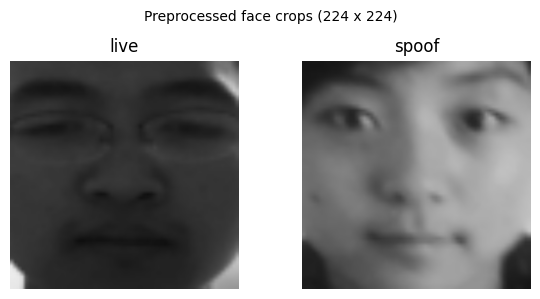

In [22]:
# Sanity check — show one live and one spoof crop
fig, axes = plt.subplots(1, 2, figsize=(6, 3))
for ax, cls in zip(axes, ('live', 'spoof')):
    sample = next((Path(CFG['processed_dir']) / cls).glob('*.png'))
    img = cv2.cvtColor(cv2.imread(str(sample)), cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(cls, fontsize=12)
    ax.axis('off')
plt.suptitle('Preprocessed face crops (224 x 224)', fontsize=10)
plt.tight_layout()
plt.show()

## Step 2 — Dataset, Augmentation & DataLoaders

In [23]:
class LivenessDataset(Dataset):
    """Binary liveness dataset.  label 1 = live,  label 0 = spoof."""

    def __init__(self, paths, labels, transform=None):
        self.paths     = list(paths)
        self.labels    = list(labels)
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, int(self.labels[idx])

In [24]:
# ── Transforms ──────────────────────────────────────────────────────────────
#
# Strong augmentation in the train set pushes the model to learn
# generalizable liveness cues (skin texture, 3-D lighting, reflection)
# rather than memorising the identity of the people in the training set.
#
train_tf = T.Compose([
    T.Resize((CFG['image_size'], CFG['image_size'])),
    # ── Geometry ──────────────────────────────────────────────────────────
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=15),                             # head tilt variation
    T.RandomPerspective(distortion_scale=0.15, p=0.4),       # viewing angle variation
    # ── Colour & lighting ─────────────────────────────────────────────────
    T.ColorJitter(brightness=0.4, contrast=0.4,
                  saturation=0.3, hue=0.08),                 # lighting changes
    T.RandomGrayscale(p=0.05),
    # ── Blur / noise — simulates focus, motion, compression ───────────────
    T.RandomApply([T.GaussianBlur(kernel_size=3, sigma=(0.1, 1.5))], p=0.3),
    # ── Tensor + normalise ────────────────────────────────────────────────
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    # ── Pixel-level dropout — prevents over-reliance on specific regions ──
    T.RandomErasing(p=0.15, scale=(0.02, 0.10), ratio=(0.3, 3.0), value=0),
])

eval_tf = T.Compose([
    T.Resize((CFG['image_size'], CFG['image_size'])),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# ── Collect all processed paths + labels ────────────────────────────────────
all_paths, all_labels = [], []
for label, cls in [(1, 'live'), (0, 'spoof')]:
    for p in sorted((Path(CFG['processed_dir']) / cls).glob('*.png')):
        all_paths.append(str(p))
        all_labels.append(label)

all_paths  = np.array(all_paths)
all_labels = np.array(all_labels)

# ── Stratified split: 70 / 15 / 15 ─────────────────────────────────────────
val_test = CFG['val_split'] + CFG['test_split']
X_tr, X_tmp, y_tr, y_tmp = train_test_split(
    all_paths, all_labels,
    test_size=val_test, stratify=all_labels, random_state=CFG['seed']
)
val_frac = CFG['val_split'] / val_test
X_val, X_te, y_val, y_te = train_test_split(
    X_tmp, y_tmp,
    test_size=1 - val_frac, stratify=y_tmp, random_state=CFG['seed']
)

for name, y in [('train', y_tr), ('val', y_val), ('test', y_te)]:
    print(f'{name:5s}: {len(y):4d}  live={y.sum()}  spoof={len(y)-y.sum()}')

# ── DataLoaders ──────────────────────────────────────────────────────────────
train_ds = LivenessDataset(X_tr,  y_tr,  transform=train_tf)
val_ds   = LivenessDataset(X_val, y_val, transform=eval_tf)
test_ds  = LivenessDataset(X_te,  y_te,  transform=eval_tf)

train_loader = DataLoader(train_ds, batch_size=CFG['batch_size'], shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=CFG['batch_size'], shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=CFG['batch_size'], shuffle=False, num_workers=0)


train: 1424  live=714  spoof=710
val  :  305  live=153  spoof=152
test :  306  live=154  spoof=152


## Step 3 — ResNet-18 Model

We load ImageNet-pretrained ResNet-18 and replace the final fully-connected layer:

```
Backbone  (frozen — weights never updated)
  └─ ...ResNet feature extractor...
Head  (trainable)
  ├─ Dropout(p=0.5)
  └─ Linear(512 → 2)          # live vs. spoof
```

Only the head parameters are passed to the optimizer.

In [25]:
def build_resnet18() -> nn.Module:
    """Pretrained ResNet-18 with a binary classification head."""
    model = tv_models.resnet18(weights=tv_models.ResNet18_Weights.IMAGENET1K_V1)

    # Freeze entire backbone
    for p in model.parameters():
        p.requires_grad = False

    # Replace final FC layer — these are the only trainable parameters
    in_feats = model.fc.in_features  # 512 for ResNet-18
    model.fc = nn.Sequential(
        nn.Dropout(p=0.5),
        nn.Linear(in_feats, len(CLASS_NAMES)),
    )
    return model.to(DEVICE)


model = build_resnet18()

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Parameters — total: {total:,}  trainable (FC head only): {trainable:,}')

Parameters — total: 11,177,538  trainable (FC head only): 1,026


## Step 4 — Training

Two-phase fine-tuning strategy:

| Phase | Epochs | Trainable layers | Learning rate |
|-------|--------|-----------------|---------------|
| 1 — warm-up | 1 → `unfreeze_epoch` | FC head only | `lr` |
| 2 — fine-tune | `unfreeze_epoch+1` → end | `layer4` + FC head | backbone: `lr/10`, head: `lr` |

Unfreezing only `layer4` (the deepest residual block, ~2.6 M params) lets the network adapt its highest-level features to the live/spoof task without disturbing the low-level texture and edge detectors in earlier layers. The lower learning rate for the backbone prevents catastrophic forgetting of the ImageNet features.


In [26]:
def _unfreeze_layer4(model: nn.Module) -> None:
    """Unfreeze layer4 and avgpool so they join the fine-tuning phase."""
    for name, p in model.named_parameters():
        if name.startswith('layer4') or name.startswith('avgpool'):
            p.requires_grad = True


def _make_optimizer(model: nn.Module, cfg: dict) -> optim.Optimizer:
    """
    Build an Adam optimizer with two parameter groups:
      • layer4 / avgpool  →  lr / 10   (gentle fine-tuning)
      • FC head           →  lr        (full learning rate)
    If layer4 is still frozen, only the head group is used.
    """
    backbone_params = [
        p for name, p in model.named_parameters()
        if p.requires_grad and not name.startswith('fc')
    ]
    head_params = list(model.fc.parameters())

    if backbone_params:
        param_groups = [
            {'params': backbone_params, 'lr': cfg['lr'] / 10},
            {'params': head_params,     'lr': cfg['lr']},
        ]
    else:
        param_groups = [{'params': head_params, 'lr': cfg['lr']}]

    return optim.Adam(param_groups, weight_decay=cfg['weight_decay'])


def train_model(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    cfg: dict,
    save_path: str,
) -> dict:
    """
    Two-phase training:
      Phase 1 (epochs 1 – unfreeze_epoch)   : FC head only (backbone frozen)
      Phase 2 (epoch unfreeze_epoch+1 – end): layer4 + FC head (differential LRs)

    Returns history dict with train_loss, val_loss, val_acc lists.
    """
    criterion      = nn.CrossEntropyLoss()
    optimizer      = _make_optimizer(model, cfg)
    scheduler      = optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=cfg['epochs'], eta_min=1e-6
    )

    best_val_loss  = float('inf')
    patience_count = 0
    history        = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    phase          = 1

    for epoch in range(1, cfg['epochs'] + 1):

        # ── Phase transition: unfreeze layer4 ────────────────────────────────
        if phase == 1 and epoch > cfg['unfreeze_epoch']:
            phase = 2
            _unfreeze_layer4(model)
            optimizer = _make_optimizer(model, cfg)
            # Restart cosine schedule over the remaining epochs
            scheduler = optim.lr_scheduler.CosineAnnealingLR(
                optimizer, T_max=cfg['epochs'] - epoch + 1, eta_min=1e-6
            )
            trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
            print(f'\n── Phase 2: layer4 unfrozen  '
                  f'(backbone LR={cfg["lr"]/10:.1e}, head LR={cfg["lr"]:.1e}, '
                  f'trainable params={trainable:,}) ──\n')

        # ── Train ─────────────────────────────────────────────────────────────
        model.train()
        running_loss = 0.0
        for imgs, labels in tqdm(train_loader, desc=f'Epoch {epoch:02d} train  [phase {phase}]', leave=False):
            imgs   = imgs.to(DEVICE)
            labels = labels.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(imgs), labels)
            loss.backward()
            # Clip gradients for all trainable parameters
            nn.utils.clip_grad_norm_(
                [p for p in model.parameters() if p.requires_grad], max_norm=1.0
            )
            optimizer.step()
            running_loss += loss.item() * imgs.size(0)
        train_loss = running_loss / len(train_loader.dataset)

        # ── Validate ──────────────────────────────────────────────────────────
        model.eval()
        val_loss = val_correct = 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs   = imgs.to(DEVICE)
                labels = labels.to(DEVICE)
                out    = model(imgs)
                val_loss    += criterion(out, labels).item() * imgs.size(0)
                val_correct += (out.argmax(1) == labels).sum().item()
        val_loss /= len(val_loader.dataset)
        val_acc   = val_correct / len(val_loader.dataset)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        scheduler.step()

        print(
            f'Epoch {epoch:02d}/{cfg["epochs"]}  '
            f'[phase {phase}]  '
            f'train_loss={train_loss:.4f}  '
            f'val_loss={val_loss:.4f}  '
            f'val_acc={val_acc:.4f}'
        )

        # ── Checkpoint ────────────────────────────────────────────────────────
        if val_loss < best_val_loss:
            best_val_loss  = val_loss
            patience_count = 0
            torch.save({
                'epoch':       epoch,
                'state_dict':  model.state_dict(),
                'val_loss':    best_val_loss,
                'val_acc':     val_acc,
                'class_names': CLASS_NAMES,
                'image_size':  cfg['image_size'],
            }, save_path)
            print(f'  → Saved best model (val_loss={best_val_loss:.4f})')
        else:
            patience_count += 1
            if patience_count >= cfg['patience']:
                print(f'  Early stopping triggered at epoch {epoch}.')
                break

    return history


SAVE_PATH = os.path.join(CFG['models_dir'], 'resnet18_best.pth')
history   = train_model(model, train_loader, val_loader, CFG, SAVE_PATH)
print(f'\nBest model saved → {SAVE_PATH}')


Epoch 01 train  [phase 1]:   0%|          | 0/45 [00:00<?, ?it/s]

Epoch 01/30  [phase 1]  train_loss=0.8226  val_loss=0.7632  val_acc=0.4230
  → Saved best model (val_loss=0.7632)


Epoch 02 train  [phase 1]:   0%|          | 0/45 [00:00<?, ?it/s]

Epoch 02/30  [phase 1]  train_loss=0.8214  val_loss=0.7432  val_acc=0.4721
  → Saved best model (val_loss=0.7432)


Epoch 03 train  [phase 1]:   0%|          | 0/45 [00:00<?, ?it/s]

...

Epoch 28/30  [phase 2]  train_loss=0.2122  val_loss=0.2178  val_acc=0.9049


Epoch 29 train  [phase 2]:   0%|          | 0/45 [00:00<?, ?it/s]

Epoch 29/30  [phase 2]  train_loss=0.2377  val_loss=0.2028  val_acc=0.9049
  → Saved best model (val_loss=0.2028)


Epoch 30 train  [phase 2]:   0%|          | 0/45 [00:00<?, ?it/s]

Epoch 30/30  [phase 2]  train_loss=0.2070  val_loss=0.2361  val_acc=0.8951

Best model saved → models/resnet18_best.pth


## Training Curves

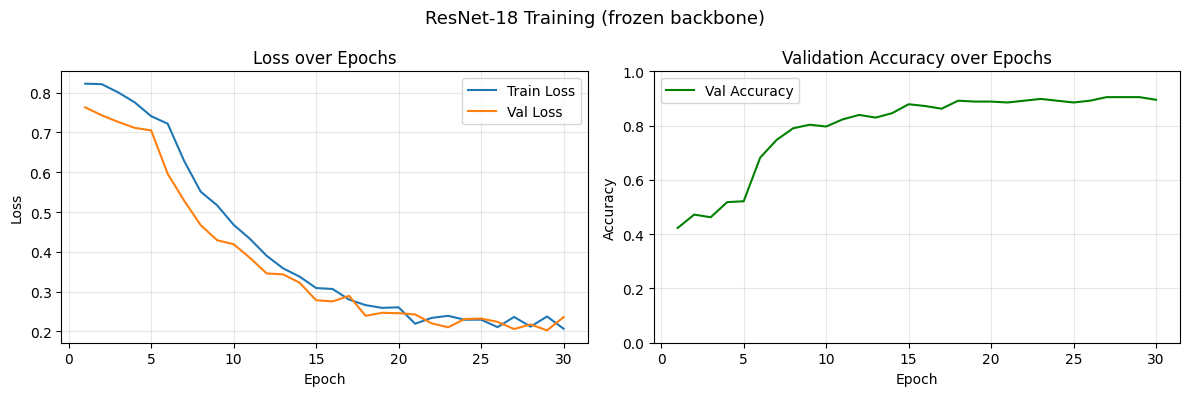

In [27]:
epochs_ran = range(1, len(history['train_loss']) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs_ran, history['train_loss'], label='Train Loss')
ax1.plot(epochs_ran, history['val_loss'],   label='Val Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss over Epochs')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_ran, history['val_acc'], color='green', label='Val Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Validation Accuracy over Epochs')
ax2.set_ylim(0, 1)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('ResNet-18 Training (frozen backbone)', fontsize=13)
plt.tight_layout()
plt.savefig(
    os.path.join(CFG['models_dir'], 'resnet18_training_curves.png'),
    dpi=150, bbox_inches='tight'
)
plt.show()

## Step 5 — Test Set Evaluation

In [28]:
# Load best checkpoint
ckpt = torch.load(SAVE_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt['state_dict'])
model.eval()
print(f"Loaded checkpoint — epoch {ckpt['epoch']}, val_loss={ckpt['val_loss']:.4f}")

# Inference on test set
all_preds  = []
all_true   = []
with torch.no_grad():
    for imgs, labels in tqdm(test_loader, desc='Testing'):
        preds = model(imgs.to(DEVICE)).argmax(dim=1).cpu().tolist()
        all_preds.extend(preds)
        all_true.extend(labels.tolist())

all_preds = np.array(all_preds)
all_true  = np.array(all_true)

# Metrics
acc              = accuracy_score(all_true, all_preds)
prec, rec, f1, _ = precision_recall_fscore_support(all_true, all_preds, average='macro')

print(f'\n=== ResNet-18 Test Results ===')
print(f'Accuracy  : {acc:.4f}')
print(f'Precision : {prec:.4f}  (macro)')
print(f'Recall    : {rec:.4f}  (macro)')
print(f'F1 Score  : {f1:.4f}  (macro)')
print()
print(classification_report(all_true, all_preds, target_names=['spoof', 'live']))

# Save results for experiments notebook
import json
result_path = os.path.join(CFG['models_dir'], 'resnet18_test_results.json')
with open(result_path, 'w') as f:
    json.dump({
        'model':     'ResNet-18',
        'accuracy':  float(acc),
        'precision': float(prec),
        'recall':    float(rec),
        'f1':        float(f1),
    }, f, indent=2)
print(f'Results saved → {result_path}')

Loaded checkpoint — epoch 29, val_loss=0.2028


Testing:   0%|          | 0/10 [00:00<?, ?it/s]


=== ResNet-18 Test Results ===
Accuracy  : 0.9150
Precision : 0.9199  (macro)
Recall    : 0.9147  (macro)
F1 Score  : 0.9147  (macro)

              precision    recall  f1-score   support

       spoof       0.96      0.86      0.91       152
        live       0.88      0.97      0.92       154

    accuracy                           0.92       306
   macro avg       0.92      0.91      0.91       306
weighted avg       0.92      0.92      0.91       306

Results saved → models/resnet18_test_results.json


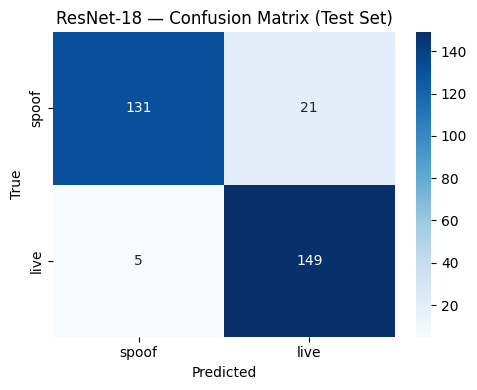

In [29]:
# Confusion matrix
cm  = confusion_matrix(all_true, all_preds)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['spoof', 'live'],
    yticklabels=['spoof', 'live'],
    ax=ax,
)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('ResNet-18 — Confusion Matrix (Test Set)')
plt.tight_layout()
plt.savefig(
    os.path.join(CFG['models_dir'], 'resnet18_confusion_matrix.png'),
    dpi=150, bbox_inches='tight'
)
plt.show()